In [2]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn plotly -q

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files
import zipfile
import os

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive connected!")

Mounted at /content/drive
✅ Google Drive connected!


In [4]:
import zipfile
import os

# Unzip the dataset from Google Drive
zip_path = '/content/drive/MyDrive/archive (11).zip'
extract_path = '/content/ecommerce_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")
print("\nFiles available:")
for file in os.listdir(extract_path):
    print(f"  📄 {file}")

✅ Dataset extracted successfully!

Files available:
  📄 olist_products_dataset.csv
  📄 olist_order_payments_dataset.csv
  📄 olist_sellers_dataset.csv
  📄 olist_orders_dataset.csv
  📄 olist_customers_dataset.csv
  📄 product_category_name_translation.csv
  📄 olist_geolocation_dataset.csv
  📄 olist_order_reviews_dataset.csv
  📄 olist_order_items_dataset.csv


In [5]:
# Load all datasets
customers = pd.read_csv('/content/ecommerce_data/olist_customers_dataset.csv')
orders = pd.read_csv('/content/ecommerce_data/olist_orders_dataset.csv')
order_items = pd.read_csv('/content/ecommerce_data/olist_order_items_dataset.csv')
payments = pd.read_csv('/content/ecommerce_data/olist_order_payments_dataset.csv')
products = pd.read_csv('/content/ecommerce_data/olist_products_dataset.csv')
reviews = pd.read_csv('/content/ecommerce_data/olist_order_reviews_dataset.csv')
category_translation = pd.read_csv('/content/ecommerce_data/product_category_name_translation.csv')

print("✅ All datasets loaded!")
print(f"\n📦 Orders: {orders.shape}")
print(f"👥 Customers: {customers.shape}")
print(f"🛍️ Order Items: {order_items.shape}")
print(f"💳 Payments: {payments.shape}")
print(f"📦 Products: {products.shape}")
print(f"⭐ Reviews: {reviews.shape}")

✅ All datasets loaded!

📦 Orders: (99441, 8)
👥 Customers: (99441, 5)
🛍️ Order Items: (112650, 7)
💳 Payments: (103886, 5)
📦 Products: (32951, 9)
⭐ Reviews: (99224, 7)


In [6]:
# Quick look at the orders dataset
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [7]:
# Check for missing values in all datasets
print("=== MISSING VALUES ===\n")
for name, df in [("Orders", orders), ("Customers", customers),
                  ("Order Items", order_items), ("Payments", payments),
                  ("Products", products), ("Reviews", reviews)]:
    missing = df.isnull().sum().sum()
    print(f"{name}: {missing} missing values")

=== MISSING VALUES ===

Orders: 4908 missing values
Customers: 0 missing values
Order Items: 0 missing values
Payments: 0 missing values
Products: 2448 missing values
Reviews: 145903 missing values


In [8]:
# Check exactly which columns have missing values in each dataset
print("=== ORDERS missing values by column ===")
print(orders.isnull().sum())

print("\n=== PRODUCTS missing values by column ===")
print(products.isnull().sum())

print("\n=== REVIEWS missing values by column ===")
print(reviews.isnull().sum())

=== ORDERS missing values by column ===
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

=== PRODUCTS missing values by column ===
product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

=== REVIEWS missing values by column ===
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: i

/tmp/ipykernel_9659/3392513958.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='viridis')


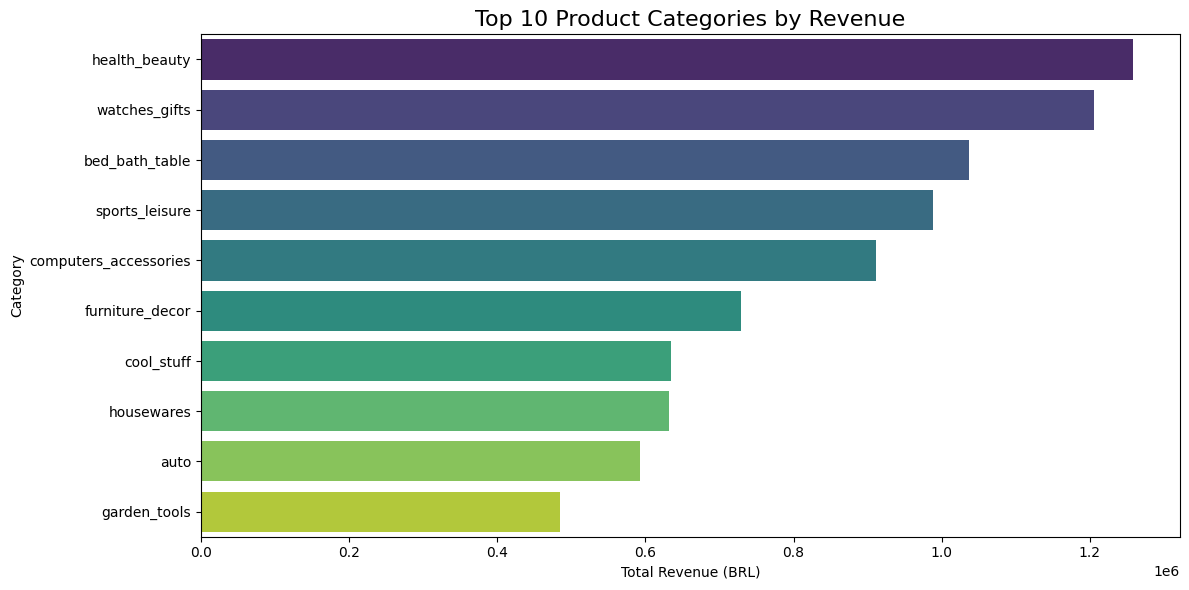


Top 10 Categories:
product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64


In [9]:
# Merge datasets to get revenue by category
df = order_items.merge(products, on='product_id')
df = df.merge(category_translation, on='product_category_name')

# Calculate revenue by category
revenue_by_category = df.groupby('product_category_name_english')['price'].sum().sort_values(ascending=False).head(10)

# Plot it
plt.figure(figsize=(12, 6))
sns.barplot(x=revenue_by_category.values, y=revenue_by_category.index, palette='viridis')
plt.title('Top 10 Product Categories by Revenue', fontsize=16)
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

print("\nTop 10 Categories:")
print(revenue_by_category)

/tmp/ipykernel_9659/3122655466.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=orders_by_state.values, y=orders_by_state.index, palette='magma')


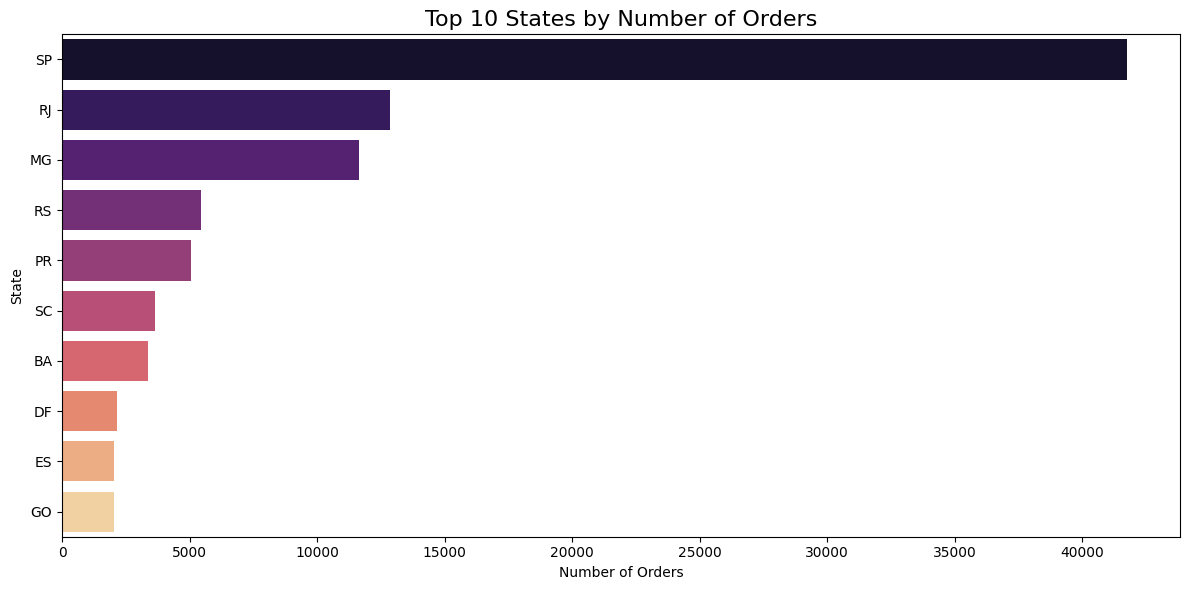


Top 10 States by Orders:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
SC     3637
BA     3380
DF     2140
ES     2033
GO     2020
Name: order_id, dtype: int64


In [10]:
# Merge orders with customers to get state info
state_orders = orders.merge(customers, on='customer_id')

# Count orders by state
orders_by_state = state_orders.groupby('customer_state')['order_id'].count().sort_values(ascending=False).head(10)

# Plot it
plt.figure(figsize=(12, 6))
sns.barplot(x=orders_by_state.values, y=orders_by_state.index, palette='magma')
plt.title('Top 10 States by Number of Orders', fontsize=16)
plt.xlabel('Number of Orders')
plt.ylabel('State')
plt.tight_layout()
plt.show()

print("\nTop 10 States by Orders:")
print(orders_by_state)

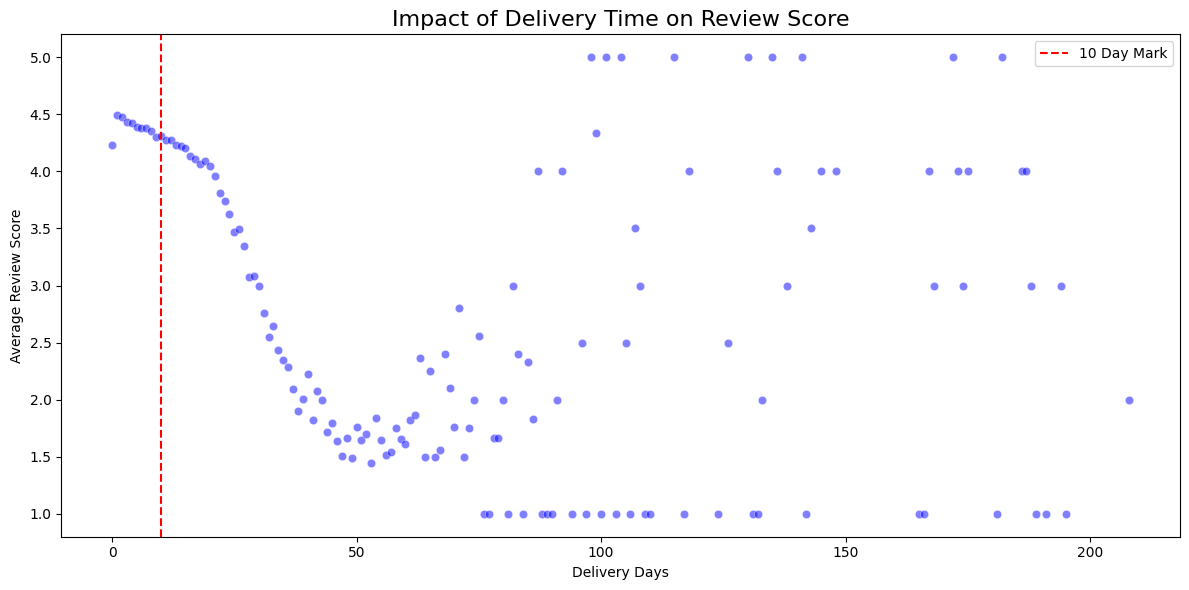

✅ Analysis complete!


In [11]:
# Convert date columns to datetime format
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'])

# Calculate actual delivery time in days
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

# Calculate if delivery was early or late
orders['days_early_or_late'] = (orders['order_estimated_delivery_date'] - orders['order_delivered_customer_date']).dt.days
# Positive = early, Negative = late

# Merge with reviews
delivery_reviews = orders.merge(reviews, on='order_id')

# Average review score by delivery days
delivery_impact = delivery_reviews.groupby('delivery_days')['review_score'].mean().reset_index()

# Plot it
plt.figure(figsize=(12, 6))
sns.scatterplot(data=delivery_impact, x='delivery_days', y='review_score', alpha=0.5, color='blue')
plt.title('Impact of Delivery Time on Review Score', fontsize=16)
plt.xlabel('Delivery Days')
plt.ylabel('Average Review Score')
plt.axvline(x=10, color='red', linestyle='--', label='10 Day Mark')
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Analysis complete!")

💰 Top 10% customers spend more than: 308.24 BRL
👥 Number of top 10% customers: 9944
💵 Average spending of top 10%: 616.58 BRL
💵 Average spending of everyone else: 110.37 BRL


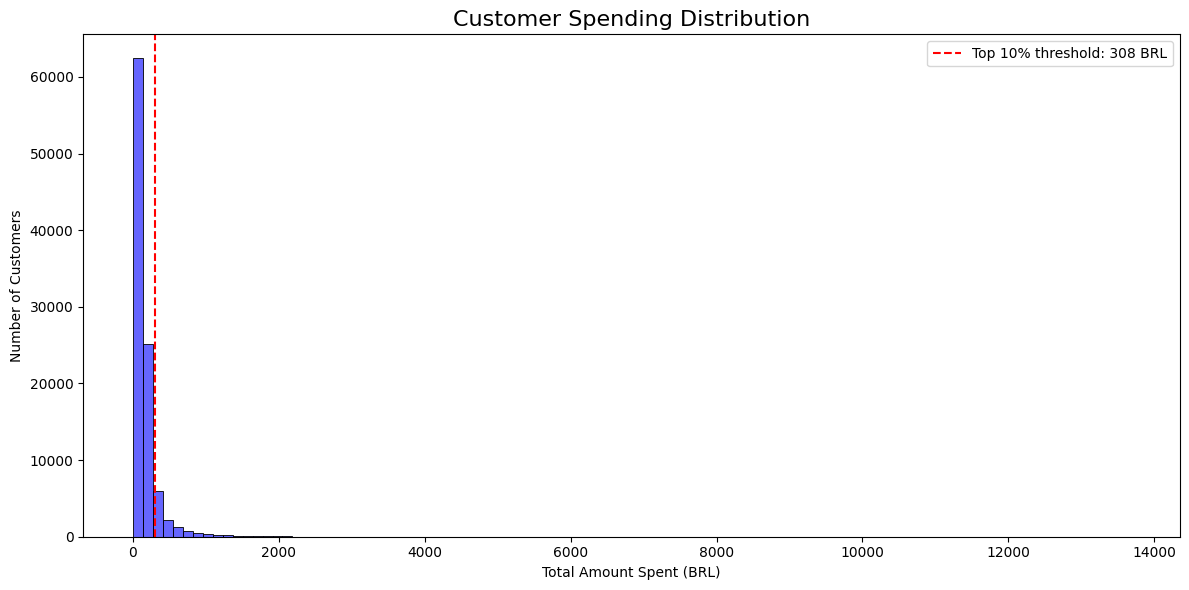

In [12]:
# Calculate total spending per customer
customer_spending = payments.merge(orders, on='order_id')
customer_spending = customer_spending.groupby('customer_id')['payment_value'].sum().reset_index()
customer_spending.columns = ['customer_id', 'total_spent']

# Calculate the 90th percentile (top 10%)
percentile_90 = customer_spending['total_spent'].quantile(0.90)
print(f"💰 Top 10% customers spend more than: {percentile_90:.2f} BRL")

# Filter top 10% customers
top_customers = customer_spending[customer_spending['total_spent'] >= percentile_90]
print(f"👥 Number of top 10% customers: {len(top_customers)}")
print(f"💵 Average spending of top 10%: {top_customers['total_spent'].mean():.2f} BRL")
print(f"💵 Average spending of everyone else: {customer_spending[customer_spending['total_spent'] < percentile_90]['total_spent'].mean():.2f} BRL")

# Plot spending distribution
plt.figure(figsize=(12, 6))
sns.histplot(customer_spending['total_spent'], bins=100, color='blue', alpha=0.6)
plt.axvline(x=percentile_90, color='red', linestyle='--', label=f'Top 10% threshold: {percentile_90:.0f} BRL')
plt.title('Customer Spending Distribution', fontsize=16)
plt.xlabel('Total Amount Spent (BRL)')
plt.ylabel('Number of Customers')
plt.legend()
plt.tight_layout()
plt.show()

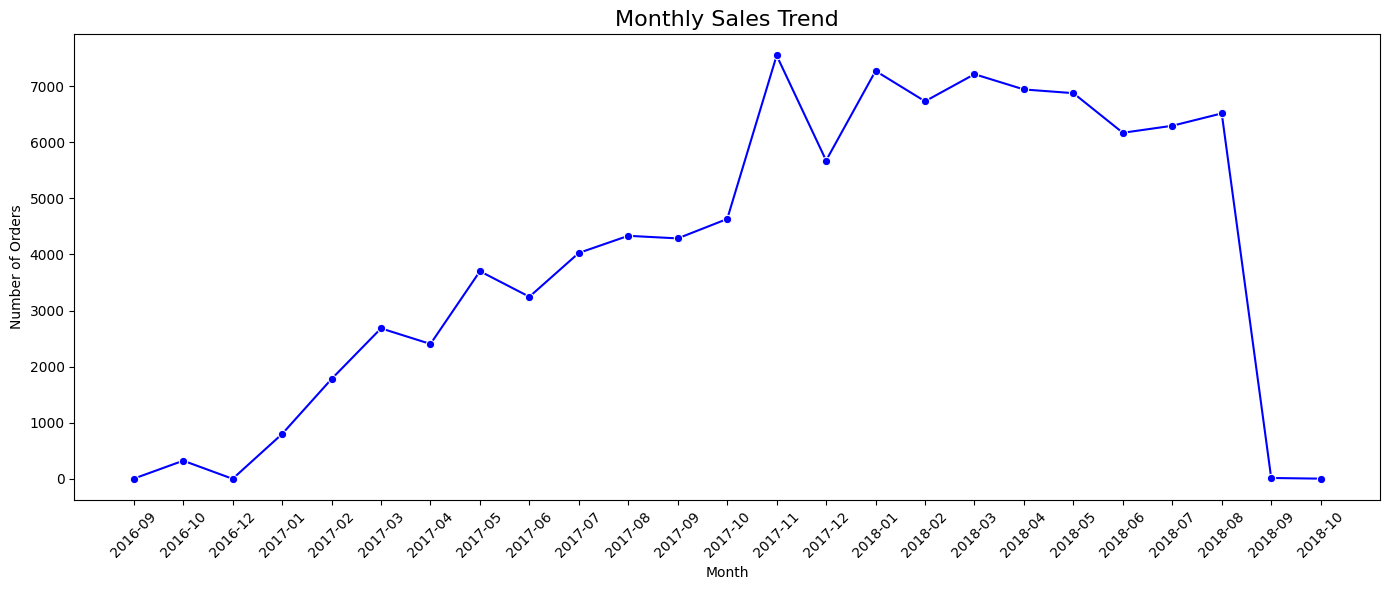


Monthly Orders:
   year_month  total_orders
0     2016-09             4
1     2016-10           324
2     2016-12             1
3     2017-01           800
4     2017-02          1780
5     2017-03          2682
6     2017-04          2404
7     2017-05          3700
8     2017-06          3245
9     2017-07          4026
10    2017-08          4331
11    2017-09          4285
12    2017-10          4631
13    2017-11          7544
14    2017-12          5673
15    2018-01          7269
16    2018-02          6728
17    2018-03          7211
18    2018-04          6939
19    2018-05          6873
20    2018-06          6167
21    2018-07          6292
22    2018-08          6512
23    2018-09            16
24    2018-10             4


In [13]:
# Convert purchase date to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])

# Extract year and month
orders['year_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

# Count orders per month
monthly_orders = orders.groupby('year_month')['order_id'].count().reset_index()
monthly_orders.columns = ['year_month', 'total_orders']
monthly_orders['year_month'] = monthly_orders['year_month'].astype(str)

# Plot it
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_orders, x='year_month', y='total_orders', marker='o', color='blue')
plt.title('Monthly Sales Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nMonthly Orders:")
print(monthly_orders)

In [14]:
# Export cleaned data to Google Drive
output_path = '/content/drive/MyDrive/ecommerce_project/'
os.makedirs(output_path, exist_ok=True)

# Save all our analysis results
monthly_orders.to_csv(output_path + 'monthly_orders.csv', index=False)
orders_by_state.to_csv(output_path + 'orders_by_state.csv')
revenue_by_category.to_csv(output_path + 'revenue_by_category.csv')
customer_spending.to_csv(output_path + 'customer_spending.csv', index=False)

print("✅ All files saved to Google Drive!")

✅ All files saved to Google Drive!


In [15]:
# Create churn labels
# A customer has "churned" if they only made ONE purchase and never returned

customer_order_count = orders.merge(customers, on='customer_id')
customer_order_count = customer_order_count.groupby('customer_unique_id')['order_id'].count().reset_index()
customer_order_count.columns = ['customer_unique_id', 'order_count']

# If customer made only 1 order = churned (1), more than 1 = retained (0)
customer_order_count['churned'] = (customer_order_count['order_count'] == 1).astype(int)

print("✅ Churn labels created!")
print(f"\nTotal customers: {len(customer_order_count)}")
print(f"Churned customers: {customer_order_count['churned'].sum()}")
print(f"Retained customers: {(customer_order_count['churned'] == 0).sum()}")
print(f"\nChurn rate: {customer_order_count['churned'].mean()*100:.1f}%")

✅ Churn labels created!

Total customers: 96096
Churned customers: 93099
Retained customers: 2997

Churn rate: 96.9%


In [16]:
# Build features for each customer
features = orders.merge(customers, on='customer_id')

# Calculate features per customer
customer_features = features.groupby('customer_unique_id').agg(
    total_orders=('order_id', 'count'),
    first_purchase=('order_purchase_timestamp', 'min'),
    last_purchase=('order_purchase_timestamp', 'max')
).reset_index()

# Merge with payments
payment_features = payments.merge(orders, on='order_id').merge(
    customers, on='customer_id')
payment_features = payment_features.groupby('customer_unique_id').agg(
    total_spent=('payment_value', 'sum'),
    avg_payment=('payment_value', 'mean')
).reset_index()

customer_features = customer_features.merge(payment_features, on='customer_unique_id')

# Merge with reviews
review_features = reviews.merge(orders, on='order_id').merge(
    customers, on='customer_id')
review_features = review_features.groupby('customer_unique_id').agg(
    avg_review_score=('review_score', 'mean')
).reset_index()

customer_features = customer_features.merge(review_features, on='customer_unique_id', how='left')

# Merge with churn labels
customer_features = customer_features.merge(customer_order_count[['customer_unique_id', 'churned']],
                                            on='customer_unique_id')

print("✅ Features created!")
print(f"\nDataset shape: {customer_features.shape}")
print("\nFeatures available:")
print(customer_features.columns.tolist())

✅ Features created!

Dataset shape: (96095, 8)

Features available:
['customer_unique_id', 'total_orders', 'first_purchase', 'last_purchase', 'total_spent', 'avg_payment', 'avg_review_score', 'churned']


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Convert dates to number of days
customer_features['first_purchase'] = pd.to_datetime(customer_features['first_purchase'])
customer_features['last_purchase'] = pd.to_datetime(customer_features['last_purchase'])

reference_date = customer_features['last_purchase'].max()

customer_features['days_since_first'] = (reference_date - customer_features['first_purchase']).dt.days
customer_features['days_since_last'] = (reference_date - customer_features['last_purchase']).dt.days

# Fill missing review scores with average
customer_features['avg_review_score'] = customer_features['avg_review_score'].fillna(customer_features['avg_review_score'].mean())

# Select features for model
X = customer_features[['total_spent', 'avg_payment', 'avg_review_score', 'days_since_first', 'days_since_last']]
y = customer_features['churned']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Data prepared!")
print(f"\nTraining set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

✅ Data prepared!

Training set: (76876, 5)
Testing set: (19219, 5)


In [18]:
# Build the Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
print("Training model... please wait ⏳")
model.fit(X_train, y_train)

# Test the model
y_pred = model.predict(X_test)

# Results
print("✅ Model trained!")
print(f"\nAccuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
print("\nDetailed Results:")
print(classification_report(y_test, y_pred))

Training model... please wait ⏳
✅ Model trained!

Accuracy: 98.8%

Detailed Results:
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       611
           1       0.99      0.99      0.99     18608

    accuracy                           0.99     19219
   macro avg       0.91      0.89      0.90     19219
weighted avg       0.99      0.99      0.99     19219



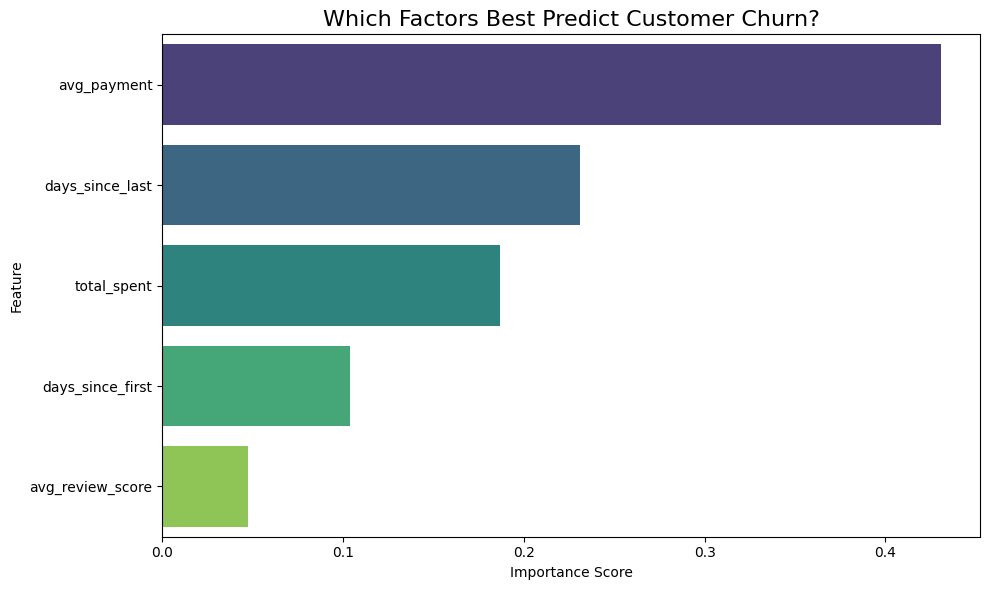


Feature Importance:
            feature  importance
1       avg_payment    0.430768
4   days_since_last    0.231296
0       total_spent    0.186640
3  days_since_first    0.104002
2  avg_review_score    0.047295


In [19]:
# Plot feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='importance', y='feature', palette='viridis')
plt.title('Which Factors Best Predict Customer Churn?', fontsize=16)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nFeature Importance:")
print(feature_importance)